# Student Performance Prediction Project
Using Machine Learning (Logistic Regression)

##  Problem
Predict whether a student will pass or fail based on demographic and academic features.

# 1-Import Libraries

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix


# 2-Load Data

In [77]:
data=pd.read_csv('StudentsPerformance.csv')
data.head(15)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# 3-Data Cleaning

In [79]:
print(data.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [80]:
print(data.duplicated().sum())

0


# 4-Encoding

In [81]:
le=LabelEncoder()
for col in["gender",
           "race/ethnicity",
           "parental level of education",
           "lunch",
           "test preparation course"]:
    data[col]=le.fit_transform(data[col])
           
           
           

data


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75
...,...,...,...,...,...,...,...,...
995,0,4,3,1,0,88,99,95
996,1,2,2,0,1,62,55,55
997,0,2,2,0,0,59,71,65
998,0,3,4,1,0,68,78,77


# 5-Feature Engineering

In [82]:
data["pass"]=((data["math score"]>=50)&
             (data["reading score"]>=50)&
             (data["writing score"]>=50)).astype(int)
data


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass
0,0,1,1,1,1,72,72,74,1
1,0,2,4,1,0,69,90,88,1
2,0,1,3,1,1,90,95,93,1
3,1,0,0,0,1,47,57,44,0
4,1,2,4,1,1,76,78,75,1
...,...,...,...,...,...,...,...,...,...
995,0,4,3,1,0,88,99,95,1
996,1,2,2,0,1,62,55,55,1
997,0,2,2,0,0,59,71,65,1
998,0,3,4,1,0,68,78,77,1


In [83]:
x=data.drop(["pass"],axis=1)
y=data["pass"]
y

0      1
1      1
2      1
3      0
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: pass, Length: 1000, dtype: int32

# 6-Train/Test Split and Scaling

In [84]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [85]:


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# 7-Model Training

In [86]:

LR=LogisticRegression(max_iter=1000)
model=LR.fit(x_train,y_train)
model

LogisticRegression(max_iter=1000)

In [87]:
y_pred=model.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

# 8-Evaluation

In [88]:
print(accuracy_score(y_test, y_pred))

0.955


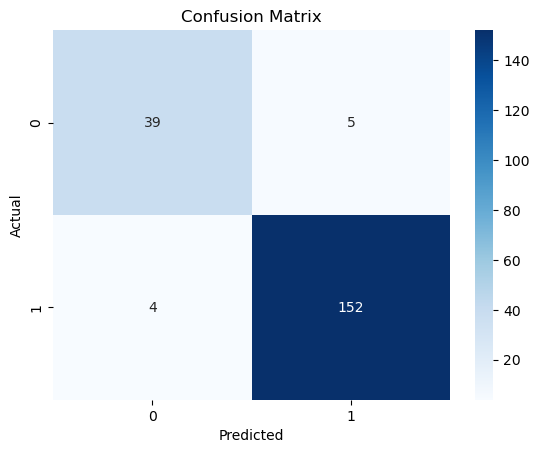

In [93]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 9-Visualizations

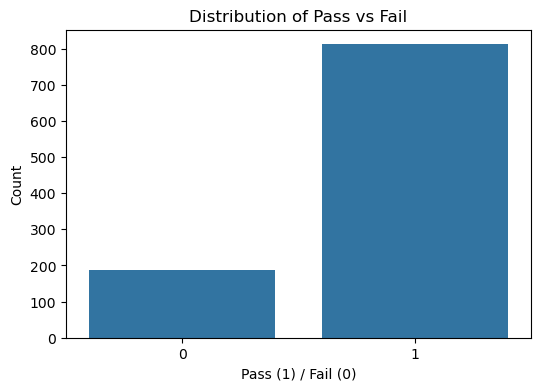

In [97]:

plt.figure(figsize=(6,4))
sns.countplot(x="pass", data=data)
plt.title("Distribution of Pass vs Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='pass', ylabel='math score'>

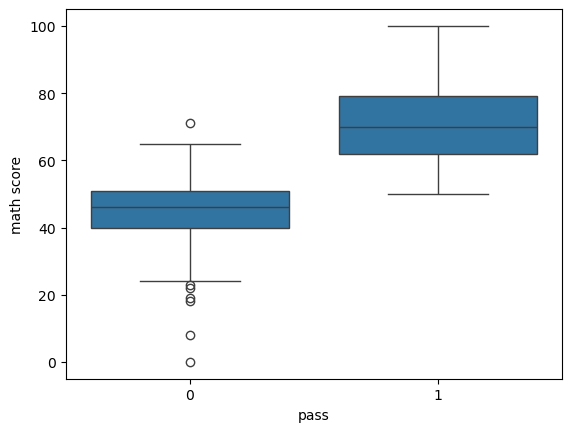

In [96]:
sns.boxplot(x="pass", y="math score", data=data)

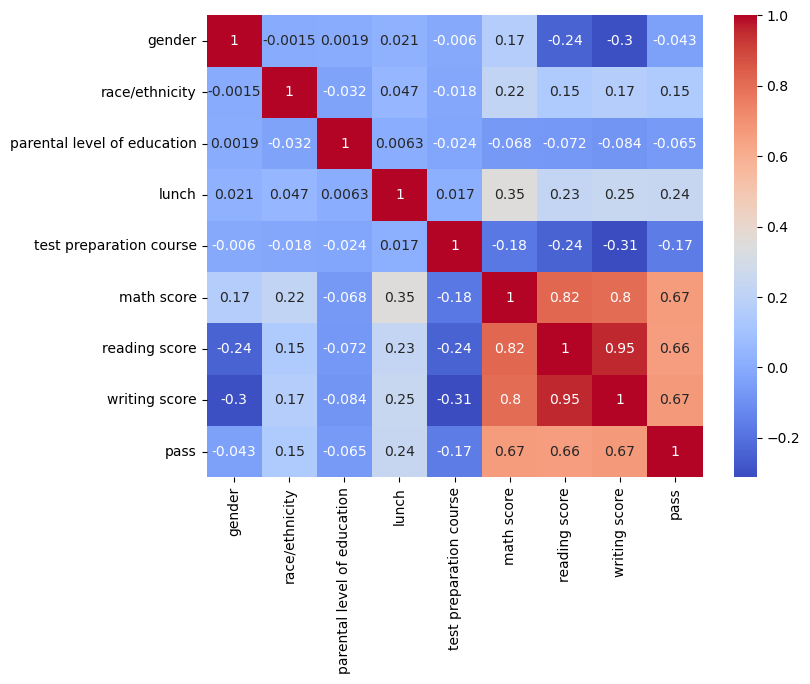

In [92]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

# 10-Conclusion
- The model achieved good accuracy
- Academic scores are strong predictors of success
- The dataset is imbalanced, which affects performance